# 02 · Transformer decoder

A Transformer decoder written from scratch (`src/models.py`), trained on the frozen ResNet-50 features from notebook 01.

- **Image side:** each of the 49 grid vectors → `Linear` to 512 → `LayerNorm` → + learned 2D position. No trainable encoder layers, so the LSTM in notebook 05 gets exactly the same input.
- **Text side:** 3 pre-LayerNorm blocks (masked self-attention → cross-attention over the grid → GELU feed-forward), output projection tied to the word embedding. Multi-head attention is hand-written.
- **Training:** AdamW, 1 epoch warmup then cosine over 20 epochs, label smoothing 0.1, bf16, best checkpoint by val CIDEr.
- **Experiments:** the first run overfits, so the same architecture is retrained with 4 regularization settings (dropout and weight decay only).

In [1]:
import json
import shutil
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from torch.utils.data import DataLoader

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import viz
from src.dataset import (PAD_IDX, UNK_IDX, CaptionDataset, ImageFeatureDataset, LengthBucketSampler, collate_captions,
                         load_processed, reference_captions, split_images)
from src.decoding import generate_captions, greedy_decode
from src.models import TransformerCaptioner, load_checkpoint
from src.train import fit, run_experiment, warmup_cosine_schedule
from src.utils import set_seed

viz.setup_style()
IMAGE_DIR = ROOT / "data" / "raw" / "Images"
RUNS_CKPT = ROOT / "checkpoints" / "runs"
RESULTS = ROOT / "results" / "transformer"
RESULTS.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda")
features, images, vocab = load_processed(ROOT / "data" / "processed")
train_images, val_images = split_images(images, "train"), split_images(images, "val")
print(f"features {features.shape} | vocab {len(vocab):,} words | train {len(train_images):,} images | val {len(val_images):,} images")

features (31014, 49, 2048) | vocab 7,414 words | train 29,000 images | val 1,014 images


## Configuration

In [2]:
MODEL_CONFIG = dict(vocab_size=len(vocab), d_model=512, n_heads=8, n_layers=3, d_ff=2048, dropout=0.1, max_len=64)
TRAIN_CONFIG = dict(
    epochs=20,
    batch_size=128,
    lr=3e-4,
    weight_decay=0.01,
    warmup_epochs=1,
    label_smoothing=0.1,
    grad_clip=1.0,
    max_words=40,  # truncate the ~0.1% of training captions longer than 40 words
    seed=42,
)
# Regularization sweep: overrides on top of the configs above.
RUNS = {
    "baseline": dict(dropout=0.1, weight_decay=0.01),
    "dropout 0.3": dict(dropout=0.3, weight_decay=0.01),
    "dropout 0.3 + wd 0.1": dict(dropout=0.3, weight_decay=0.1),
    "dropout 0.5 + wd 0.1": dict(dropout=0.5, weight_decay=0.1),
}
display(viz.table(pd.DataFrame([{"run": k, **v} for k, v in RUNS.items()]), caption="Runs",
                  formats={"dropout": "{:g}", "weight_decay": "{:g}"}))

run,dropout,weight_decay
baseline,0.1,0.01
dropout 0.3,0.3,0.01
dropout 0.3 + wd 0.1,0.3,0.1
dropout 0.5 + wd 0.1,0.5,0.1


## Data
Features stay on disk as a memmap. Batches are **length-bucketed**: shuffled indices are sorted by caption length inside chunks, which removes most padding.

In [3]:
set_seed(TRAIN_CONFIG["seed"])
train_set = CaptionDataset(features, train_images, vocab, TRAIN_CONFIG["max_words"])
val_set = CaptionDataset(features, val_images, vocab, TRAIN_CONFIG["max_words"])
train_sampler = LengthBucketSampler(train_set.lengths, TRAIN_CONFIG["batch_size"])
train_loader = DataLoader(train_set, batch_sampler=train_sampler, collate_fn=collate_captions, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=256, collate_fn=collate_captions, pin_memory=True)
val_image_loader = DataLoader(ImageFeatureDataset(features, val_images), batch_size=256)
val_refs = reference_captions(val_images)

lengths = np.array(train_set.lengths)
random_pad = np.mean([lengths[b].max() for b in np.array_split(np.random.permutation(len(lengths)), len(train_sampler))])
bucket_pad = np.mean([lengths[b].max() for b in train_sampler._batches()])
display(viz.table(pd.DataFrame([
    {"item": "caption pairs (train / val)", "value": f"{len(train_set):,} / {len(val_set):,}"},
    {"item": "steps per epoch", "value": f"{len(train_loader):,}"},
    {"item": "mean caption length (tokens incl. <sos>/<eos>)", "value": f"{lengths.mean():.1f}"},
    {"item": "mean padded batch length, random batches", "value": f"{random_pad:.1f}"},
    {"item": "mean padded batch length, length-bucketed", "value": f"{bucket_pad:.1f}"},
]), caption="Training data"))

feats, caps = next(iter(train_loader))
print("batch:", tuple(feats.shape), feats.dtype, "|", tuple(caps.shape), caps.dtype)
print("example:", vocab.decode(caps[0, 1:]))

item,value
caption pairs (train / val),"145,000 / 5,070"
steps per epoch,"1,132"
mean caption length (tokens incl. <sos>/<eos>),14.3
"mean padded batch length, random batches",35.3
"mean padded batch length, length-bucketed",14.7


batch: (128, 49, 2048) torch.float16 | (128, 12) torch.int64
example: two boxers wearing protective gear are fighting with onlookers watching


## Model

In [4]:
model = TransformerCaptioner(**MODEL_CONFIG).to(device)


def n_params(*parts):
    return sum(p.numel() for part in parts for p in (part.parameters() if isinstance(part, nn.Module) else [part]))


display(viz.table(pd.DataFrame([
    {"component": "image projection + 2D position", "parameters": n_params(model.feat_proj, model.feat_norm, model.row_embed, model.col_embed)},
    {"component": "word embedding (tied with output) + 1D position", "parameters": n_params(model.tok_embed, model.out_bias, model.pos_embed)},
    {"component": f"{len(model.layers)} decoder layers", "parameters": n_params(model.layers)},
    {"component": "final LayerNorm", "parameters": n_params(model.final_norm)},
    {"component": "total", "parameters": n_params(model)},
]), caption="Parameters"))

component,parameters
image projection + 2D position,"1,057,280"
word embedding (tied with output) + 1D position,"3,836,150"
3 decoder layers,"12,612,096"
final LayerNorm,"1,024"
total,"17,506,550"


## Sanity checks before training
Initial loss should be ≈ ln(vocab size), the causal mask must not leak future tokens, and a fresh model should memorise 16 captions word for word.

In [5]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
feats, caps = feats.to(device), caps.to(device)
checks = []

model.eval()
with torch.no_grad():
    logits = model(feats, caps[:, :-1])
    init_loss = criterion(logits.flatten(0, 1), caps[:, 1:].flatten()).item()
    checks.append({"check": "initial loss vs ln(V)", "result": f"{init_loss:.3f} vs {np.log(len(vocab)):.3f}",
                   "pass": abs(init_loss - np.log(len(vocab))) < 0.5})
    t = caps.size(1) // 2
    corrupted = caps[:, :-1].clone()
    corrupted[:, t:] = torch.randint(4, len(vocab), corrupted[:, t:].shape, device=device)
    logits2 = model(feats, corrupted)
    unchanged = torch.allclose(logits[:, :t], logits2[:, :t], atol=1e-5)
    changed = not torch.allclose(logits[:, t:], logits2[:, t:], atol=1e-5)
    checks.append({"check": f"corrupt tokens from position {t}: earlier logits unchanged, later changed",
                   "result": f"{unchanged} / {changed}", "pass": unchanged and changed})

set_seed(0)
probe = TransformerCaptioner(**{**MODEL_CONFIG, "dropout": 0.0}).to(device)
probe_opt = torch.optim.AdamW(probe.parameters(), lr=5e-4)
# Samples are stored image by image (5 captions each); two captions of one image share identical input features,
# so no model could reproduce both.
# First caption of 16 different images, skipping captions with <unk> (decoding never emits <unk>).
probe_idx = [i for i in range(0, len(train_set), 5) if UNK_IDX not in train_set.samples[i][1]][:16]
small_f, small_c = [t.to(device) for t in collate_captions([train_set[i] for i in probe_idx])]
for step in range(300):
    with torch.autocast("cuda", dtype=torch.bfloat16):
        loss = criterion(probe(small_f, small_c[:, :-1]).float().flatten(0, 1), small_c[:, 1:].flatten())
    probe_opt.zero_grad()
    loss.backward()
    probe_opt.step()
probe.eval()
recon = [vocab.decode(s) for s in greedy_decode(probe, small_f, max_len=45)]
targets = [vocab.decode(c[1:]) for c in small_c]
exact = sum(r == t for r, t in zip(recon, targets))
checks.append({"check": "overfit 16 captions (16 images) for 300 steps", "result": f"loss {loss.item():.4f}, {exact}/16 reproduced exactly",
               "pass": exact == 16})
del probe, probe_opt

display(viz.table(pd.DataFrame(checks), caption="Sanity checks"))

check,result,pass
initial loss vs ln(V),9.132 vs 8.911,True
"corrupt tokens from position 6: earlier logits unchanged, later changed",True / True,True
overfit 16 captions (16 images) for 300 steps,"loss 0.0019, 16/16 reproduced exactly",True


## Learning-rate schedule

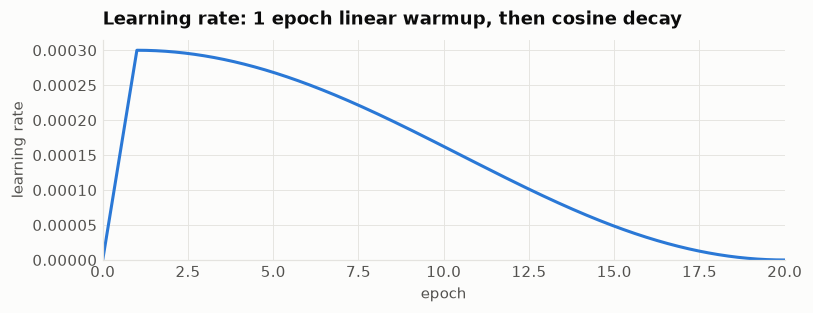

In [6]:
steps_per_epoch, total_epochs = len(train_loader), TRAIN_CONFIG["epochs"]
dummy_opt = torch.optim.AdamW([nn.Parameter(torch.zeros(1))], lr=TRAIN_CONFIG["lr"])
sched = warmup_cosine_schedule(dummy_opt, TRAIN_CONFIG["warmup_epochs"] * steps_per_epoch, total_epochs * steps_per_epoch)
lrs = []
for _ in range(total_epochs * steps_per_epoch):
    lrs.append(sched.get_last_lr()[0])
    dummy_opt.step()
    sched.step()

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.plot(np.arange(len(lrs)) / steps_per_epoch, lrs)
ax.set(xlabel="epoch", ylabel="learning rate", title="Learning rate: 1 epoch linear warmup, then cosine decay")
ax.set_xlim(0, total_epochs)
ax.set_ylim(0, None)
plt.show()

## Training runs
Each run's table updates live; highlighted cells mark its best epoch. BLEU-4 and CIDEr come from greedy decoding on val (fast metrics; official numbers are in notebook 04). Finished runs load from disk instead of retraining.

In [7]:
histories = {}
for name, overrides in RUNS.items():
    slug = name.replace(" + ", "_").replace(" ", "")
    model_cfg = {**MODEL_CONFIG, "dropout": overrides["dropout"]}
    train_cfg = {**TRAIN_CONFIG, **overrides}
    live = viz.LiveTable(
        f"Run: {name}",
        {"epoch": "epoch", "lr_start": "lr", "train_loss": "train loss", "val_loss": "val loss",
         "val_bleu4": "BLEU-4", "val_cider": "CIDEr", "seconds": "sec"},
        maximize=["val_cider"], minimize=["val_loss"],
        formats={"lr_start": "{:.1e}", "seconds": "{:.0f}"},
    )

    def train_fn(model, train_cfg=train_cfg, model_cfg=model_cfg, slug=slug, live=live):
        return fit(
            model, train_loader, val_loader, val_image_loader, val_refs, vocab, device,
            epochs=train_cfg["epochs"], lr=train_cfg["lr"], weight_decay=train_cfg["weight_decay"],
            warmup_epochs=train_cfg["warmup_epochs"], label_smoothing=train_cfg["label_smoothing"],
            grad_clip=train_cfg["grad_clip"], ckpt_path=RUNS_CKPT / f"transformer_{slug}.pt",
            run_config={"model": model_cfg, "train": train_cfg}, on_epoch_end=live,
        )

    history, cached = run_experiment(
        name, lambda cfg=model_cfg: TransformerCaptioner(**cfg).to(device), train_fn,
        ckpt_path=RUNS_CKPT / f"transformer_{slug}.pt", history_path=RESULTS / "runs" / slug / "history.json",
        seed=TRAIN_CONFIG["seed"],
    )
    if cached:
        live(history)
    histories[name] = history

epoch,lr,train loss,val loss,BLEU-4,CIDEr,sec
1,2.7e-07,5.166,3.438,0.129,0.244,54
2,3.0e-04,4.031,3.069,0.209,0.409,36
3,3.0e-04,3.796,2.956,0.202,0.380,35
4,2.9e-04,3.668,2.897,0.219,0.433,35
5,2.8e-04,3.568,2.875,0.220,0.409,38
6,2.7e-04,3.483,2.848,0.216,0.435,41
7,2.5e-04,3.405,2.855,0.210,0.432,37
8,2.3e-04,3.334,2.845,0.207,0.403,38
9,2.1e-04,3.263,2.845,0.213,0.436,35
10,1.9e-04,3.199,2.854,0.208,0.437,36


epoch,lr,train loss,val loss,BLEU-4,CIDEr,sec
1,2.7e-07,5.364,3.615,0.156,0.268,36
2,3.0e-04,4.227,3.201,0.211,0.382,35
3,3.0e-04,4.000,3.071,0.207,0.370,35
4,2.9e-04,3.889,2.989,0.215,0.395,36
5,2.8e-04,3.813,2.950,0.223,0.408,35
6,2.7e-04,3.756,2.908,0.211,0.398,35
7,2.5e-04,3.708,2.894,0.213,0.424,35
8,2.3e-04,3.667,2.862,0.222,0.420,35
9,2.1e-04,3.628,2.836,0.217,0.434,35
10,1.9e-04,3.594,2.820,0.212,0.431,35


epoch,lr,train loss,val loss,BLEU-4,CIDEr,sec
1,2.7e-07,5.364,3.615,0.155,0.264,35
2,3.0e-04,4.228,3.201,0.210,0.380,35
3,3.0e-04,4.001,3.072,0.205,0.363,35
4,2.9e-04,3.890,2.991,0.213,0.396,36
5,2.8e-04,3.815,2.951,0.223,0.408,36
6,2.7e-04,3.757,2.908,0.210,0.399,35
7,2.5e-04,3.709,2.896,0.219,0.427,35
8,2.3e-04,3.668,2.860,0.224,0.429,35
9,2.1e-04,3.628,2.834,0.214,0.432,35
10,1.9e-04,3.593,2.817,0.209,0.431,35


epoch,lr,train loss,val loss,BLEU-4,CIDEr,sec
1,2.7e-07,5.590,3.906,0.125,0.240,36
2,3.0e-04,4.463,3.456,0.189,0.321,35
3,3.0e-04,4.241,3.318,0.198,0.330,35
4,2.9e-04,4.134,3.223,0.197,0.351,35
5,2.8e-04,4.065,3.180,0.193,0.349,36
6,2.7e-04,4.015,3.123,0.191,0.349,36
7,2.5e-04,3.973,3.100,0.206,0.379,35
8,2.3e-04,3.940,3.064,0.212,0.376,34
9,2.1e-04,3.910,3.028,0.197,0.377,35
10,1.9e-04,3.884,3.005,0.204,0.394,36


## Comparing the runs

run,dropout,weight decay,best epoch,val CIDEr,val BLEU-4,lowest val loss,at epoch,final train loss,minutes
baseline,0.1,0.01,11,0.443,0.201,2.845,8,2.827,12.5
dropout 0.3,0.3,0.01,15,0.473,0.230,2.787,19,3.408,11.8
dropout 0.3 + wd 0.1,0.3,0.1,14,0.476,0.231,2.781,19,3.392,12.3
dropout 0.5 + wd 0.1,0.5,0.1,15,0.429,0.227,2.938,19,3.749,11.8


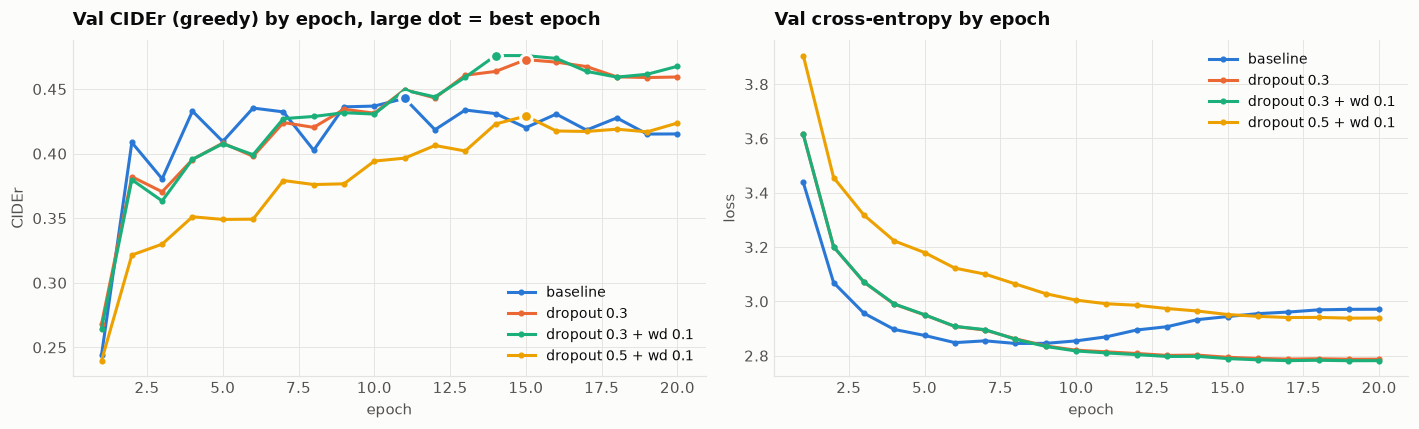

In [8]:
rows = []
for name, hist in histories.items():
    h = pd.DataFrame(hist)
    best, low = h.loc[h.val_cider.idxmax()], h.loc[h.val_loss.idxmin()]
    rows.append({
        "run": name, "dropout": RUNS[name]["dropout"], "weight decay": RUNS[name]["weight_decay"],
        "best epoch": int(best.epoch), "val CIDEr": best.val_cider, "val BLEU-4": best.val_bleu4,
        "lowest val loss": low.val_loss, "at epoch": int(low.epoch),
        "final train loss": h.train_loss.iloc[-1], "minutes": h.seconds.sum() / 60,
    })
summary = pd.DataFrame(rows)
summary.to_csv(RESULTS / "runs_summary.csv", index=False)
display(viz.table(summary, maximize=["val CIDEr", "val BLEU-4"], minimize=["lowest val loss"],
                  caption="Transformer runs (val set, greedy decoding)",
                  formats={"dropout": "{:g}", "weight decay": "{:g}", "minutes": "{:.1f}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, hist in histories.items():
    h = pd.DataFrame(hist)
    line, = axes[0].plot(h.epoch, h.val_cider, marker="o", ms=3, label=name)
    b = h.loc[h.val_cider.idxmax()]
    axes[0].scatter(b.epoch, b.val_cider, s=60, color=line.get_color(), edgecolor=viz.SURFACE, linewidth=2, zorder=3)
    axes[1].plot(h.epoch, h.val_loss, marker="o", ms=3, label=name)
axes[0].set(title="Val CIDEr (greedy) by epoch, large dot = best epoch", xlabel="epoch", ylabel="CIDEr")
axes[1].set(title="Val cross-entropy by epoch", xlabel="epoch", ylabel="loss")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "runs_comparison.png")
plt.show()

## Selected model
The best val CIDEr run is copied to `checkpoints/transformer_xe.pt`, which later notebooks load.

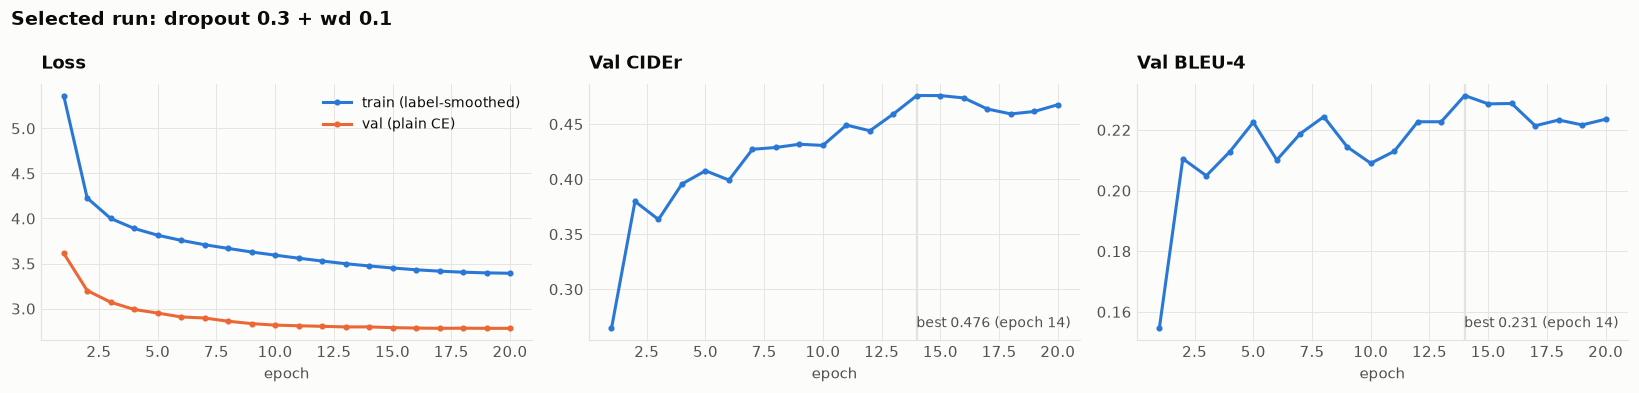

In [9]:
best_run = summary.loc[summary["val CIDEr"].idxmax(), "run"]
best_slug = best_run.replace(" + ", "_").replace(" ", "")
shutil.copy(RUNS_CKPT / f"transformer_{best_slug}.pt", ROOT / "checkpoints" / "transformer_xe.pt")
(RESULTS / "selected_run.json").write_text(json.dumps({"run": best_run, **RUNS[best_run]}, indent=2))

model, ckpt = load_checkpoint(ROOT / "checkpoints" / "transformer_xe.pt", device)
viz.note(f"Selected run: <b>{best_run}</b>, epoch {ckpt['epoch']}, "
         f"val CIDEr <b>{ckpt['val_scores']['CIDEr']:.3f}</b>, BLEU-4 {ckpt['val_scores']['BLEU-4']:.3f}")

h = pd.DataFrame(histories[best_run])
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].plot(h.epoch, h.train_loss, marker="o", ms=3, label="train (label-smoothed)")
axes[0].plot(h.epoch, h.val_loss, marker="o", ms=3, label="val (plain CE)")
axes[0].set(title="Loss", xlabel="epoch")
axes[0].legend()
for ax, col, title in [(axes[1], "val_cider", "Val CIDEr"), (axes[2], "val_bleu4", "Val BLEU-4")]:
    ax.plot(h.epoch, h[col], marker="o", ms=3, color=viz.SERIES[0])
    ax.axvline(ckpt["epoch"], color=viz.GRID, lw=1.5, zorder=0)
    ax.text(0.98, 0.05, f"best {h[col].max():.3f} (epoch {int(h.loc[h[col].idxmax(), 'epoch'])})",
            transform=ax.transAxes, ha="right", color=viz.INK_2, fontsize=9)
    ax.set(title=title, xlabel="epoch")
fig.suptitle(f"Selected run: {best_run}", x=0.01, ha="left", fontsize=12.5, weight="bold")
plt.tight_layout()
plt.savefig(RESULTS / "training_curves.png")
plt.show()

## Captions from the selected model (val images, greedy)

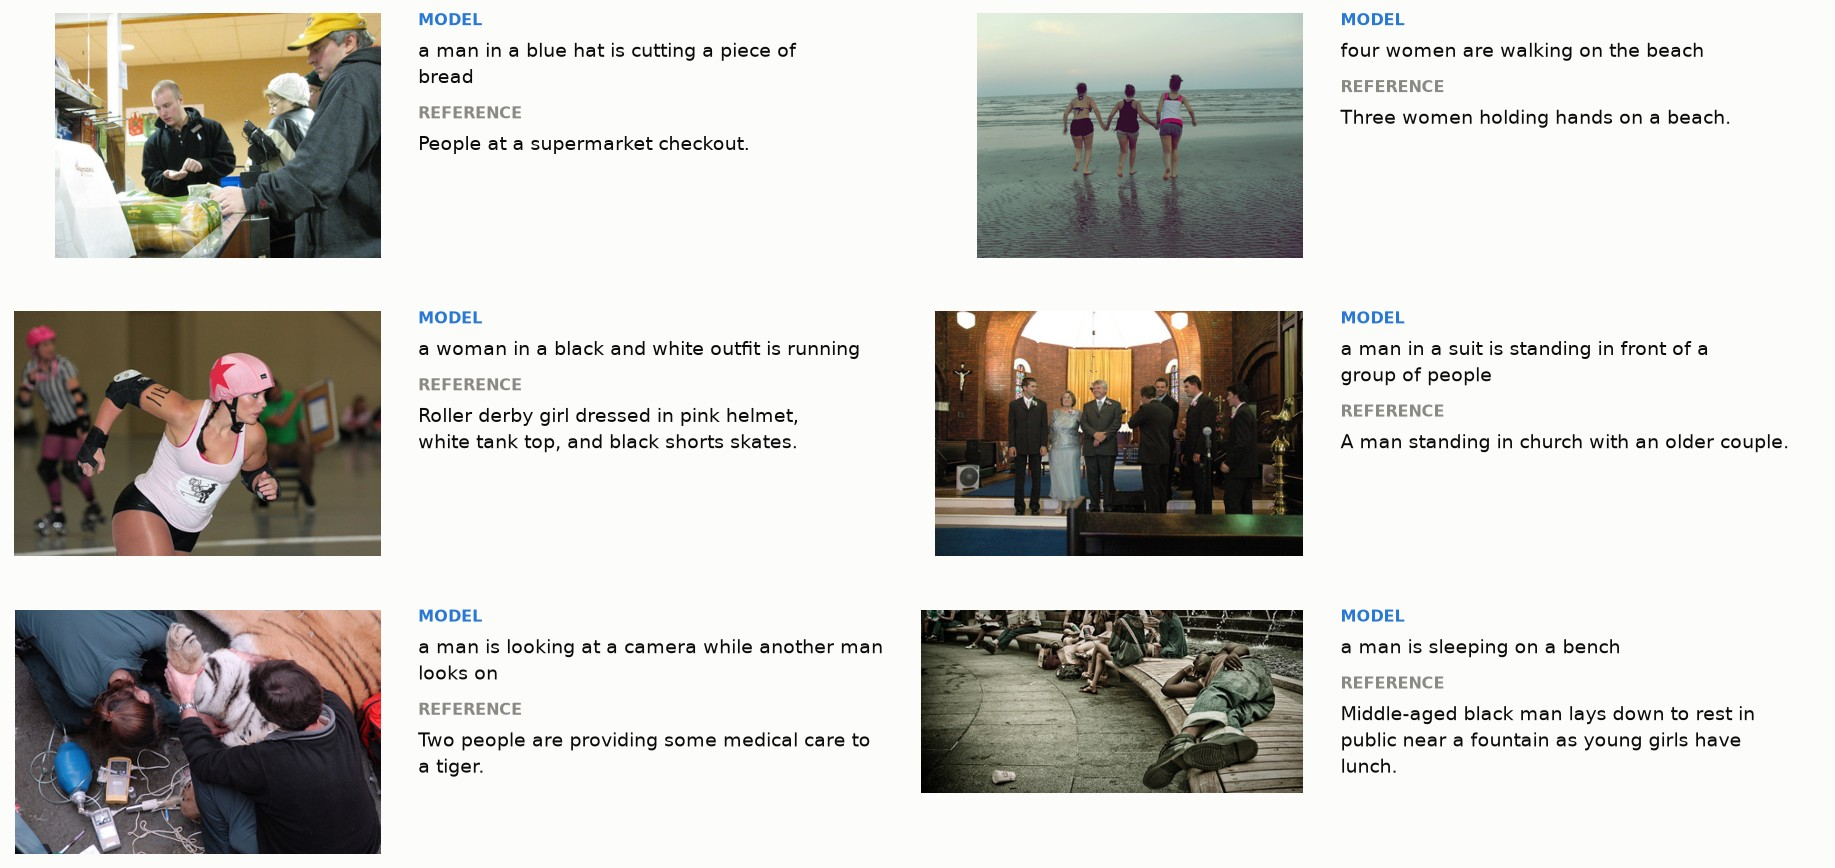

In [10]:
val_captions = generate_captions(model, val_image_loader, vocab, device)
rng = np.random.default_rng(7)
examples = []
for img in rng.choice(val_images, 6, replace=False):
    examples.append({"filename": img["filename"], "captions": [
        ("model", val_captions[img["filename"]]), ("reference", rng.choice(img["captions"]))]})
viz.show_captions(examples, IMAGE_DIR, colors={"model": viz.SERIES[0], "reference": viz.INK_3})

## Summary

- All three sanity checks pass: initial loss 9.13 vs ln(V) 8.91, no leakage through the causal mask, 16/16 captions memorised.
- **The baseline overfits**: val loss bottoms out at epoch 8, val CIDEr peaks at 0.443.
- **Dropout 0.3 + weight decay 0.1 fixes it**: val CIDEr **0.476 (+7.5%)**, BLEU-4 0.201 → 0.231. Dropout 0.5 over-regularizes (0.429).
- Selected run (epoch 14) → `checkpoints/transformer_xe.pt`. About 12 min per 20-epoch run.